# Part C: PPO Training on Old Part 1b Environment
This fallback notebook trains PPO on the smaller old bed-allocation environment from Part 1b.

## Install Requirements
Install from `requirements.txt` if available, otherwise install the minimum PPO dependencies.

In [1]:
import os
import sys
import subprocess


def install_requirements():
    if os.path.exists("requirements.txt"):
        print("Installing dependencies from requirements.txt...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    else:
        print("requirements.txt not found. Installing minimum required packages...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install",
            "stable-baselines3", "gymnasium", "numpy", "pandas", "matplotlib", "torch"
        ])


install_requirements()


Installing dependencies from requirements.txt...


## Import Compatibility Guard
These settings avoid common TensorBoard/protobuf import issues in local notebook environments.

In [2]:
import os
import sys
import types
import numpy as np

os.environ.setdefault("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION", "python")
os.environ.setdefault("TENSORBOARD_NO_TENSORFLOW", "1")
sys.modules.setdefault("tensorboard.compat.notf", types.ModuleType("tensorboard.compat.notf"))
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_


## Imports
These imports support PPO training, evaluation, plotting, and the old environment script.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor

from old_hospital_bed_env import ACTION_MEANINGS, OldHospitalBedPPOEnv


## CUDA / Device Check
PPO uses CUDA when available, otherwise it falls back to CPU.

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Selected device: {DEVICE}")

if DEVICE == "cuda":
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available. Training will run on CPU.")


Selected device: cuda
GPU name: NVIDIA GeForce RTX 3060 Laptop GPU


## Environment Factory
The factory wraps the old environment with `Monitor` for Stable-Baselines3.

In [7]:
def make_old_env():
    return Monitor(OldHospitalBedPPOEnv())


## PPO Training Function
This trains PPO on the old three-action bed-allocation task.

In [ ]:
def train_old_env_ppo(total_timesteps=50000, seed=42):
    train_env = make_old_env()

    model = PPO(
        policy="MlpPolicy",
        env=train_env,
        learning_rate=3e-4,
        n_steps=512,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        verbose=1,
        seed=seed,
        device=DEVICE,
    )

    model.learn(total_timesteps=total_timesteps)
    return model


## PPO Evaluation Function
Evaluation records reward, emergency rejections, utilisation, delays, and action counts.

In [9]:
def evaluate_model(model, n_episodes=100, seed=42):
    env = OldHospitalBedPPOEnv()
    rows = []
    action_counts = {action: 0 for action in ACTION_MEANINGS}

    for episode in range(n_episodes):
        obs, info = env.reset(seed=seed + episode)
        done = False
        total_reward = 0.0
        emergency_rejections = 0
        icu_values = []
        general_values = []
        delayed_patients = 0
        steps = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            action = int(np.asarray(action).item())
            action_counts[action] += 1

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += float(reward)
            emergency_rejections += int(info.get("emergency_rejection", 0))
            icu_values.append(float(info.get("icu_utilisation", 0.0)))
            general_values.append(float(info.get("general_utilisation", 0.0)))
            delayed_patients += int(action == 2)
            steps += 1

        rows.append({
            "episode": episode,
            "total_reward": total_reward,
            "steps": steps,
            "emergency_rejections": emergency_rejections,
            "mean_icu_utilisation": float(np.mean(icu_values)) if icu_values else 0.0,
            "mean_general_utilisation": float(np.mean(general_values)) if general_values else 0.0,
            "delayed_patients": delayed_patients,
        })

    action_counts_df = pd.DataFrame({
        "action": list(action_counts.keys()),
        "action_name": [ACTION_MEANINGS[action] for action in action_counts],
        "count": list(action_counts.values()),
    })
    return pd.DataFrame(rows), action_counts_df


## Random Baseline Evaluation
The random baseline uses the same old environment and metrics as PPO.

In [10]:
def evaluate_random_policy(n_episodes=100, seed=42):
    rng = np.random.default_rng(seed)
    env = OldHospitalBedPPOEnv()
    rows = []

    for episode in range(n_episodes):
        obs, info = env.reset(seed=seed + episode)
        done = False
        total_reward = 0.0
        emergency_rejections = 0
        icu_values = []
        general_values = []
        delayed_patients = 0
        steps = 0

        while not done:
            action = int(rng.integers(env.action_space.n))
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += float(reward)
            emergency_rejections += int(info.get("emergency_rejection", 0))
            icu_values.append(float(info.get("icu_utilisation", 0.0)))
            general_values.append(float(info.get("general_utilisation", 0.0)))
            delayed_patients += int(action == 2)
            steps += 1

        rows.append({
            "episode": episode,
            "total_reward": total_reward,
            "steps": steps,
            "emergency_rejections": emergency_rejections,
            "mean_icu_utilisation": float(np.mean(icu_values)) if icu_values else 0.0,
            "mean_general_utilisation": float(np.mean(general_values)) if general_values else 0.0,
            "delayed_patients": delayed_patients,
        })

    return pd.DataFrame(rows)


## Summary Function
This compares PPO and random performance using old-environment metrics.

In [11]:
def summarise_results(ppo_results, random_results):
    metrics = [
        "total_reward",
        "emergency_rejections",
        "mean_icu_utilisation",
        "mean_general_utilisation",
        "delayed_patients",
    ]
    rows = []

    for metric in metrics:
        rows.append({
            "metric": metric,
            "ppo_mean": ppo_results[metric].mean(),
            "ppo_std": ppo_results[metric].std(),
            "random_mean": random_results[metric].mean(),
            "random_std": random_results[metric].std(),
        })

    return pd.DataFrame(rows)


## Plotting Function
These plots show reward, emergency rejection, utilisation, and PPO action frequencies.

In [12]:
def plot_old_env_results(ppo_results, random_results, action_counts_df):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(ppo_results["episode"], ppo_results["total_reward"], label="PPO")
    axes[0].plot(random_results["episode"], random_results["total_reward"], label="Random", alpha=0.7)
    axes[0].set_title("Episode Reward")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Reward")
    axes[0].legend()

    axes[1].plot(ppo_results["episode"], ppo_results["emergency_rejections"], label="PPO")
    axes[1].plot(random_results["episode"], random_results["emergency_rejections"], label="Random", alpha=0.7)
    axes[1].set_title("Emergency Rejections")
    axes[1].set_xlabel("Episode")
    axes[1].legend()

    axes[2].plot(ppo_results["episode"], ppo_results["mean_icu_utilisation"], label="PPO ICU")
    axes[2].plot(random_results["episode"], random_results["mean_icu_utilisation"], label="Random ICU", alpha=0.7)
    axes[2].set_title("ICU Utilisation")
    axes[2].set_xlabel("Episode")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.bar(action_counts_df["action_name"], action_counts_df["count"])
    plt.title("PPO Action Frequencies")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


## Save Results Function
Outputs use old-env filenames so they do not overwrite the richer PPO notebook results.

In [13]:
def save_old_env_results(model, ppo_results, random_results, summary_df, action_counts_df):
    model.save("ppo_old_env_model")
    ppo_results.to_csv("ppo_old_env_evaluation_results.csv", index=False)
    random_results.to_csv("random_old_env_results.csv", index=False)
    summary_df.to_csv("ppo_old_env_vs_random_summary.csv", index=False)
    action_counts_df.to_csv("ppo_old_env_action_counts.csv", index=False)

    print("Saved PPO model: ppo_old_env_model.zip")
    print("Saved PPO results: ppo_old_env_evaluation_results.csv")
    print("Saved random baseline: random_old_env_results.csv")
    print("Saved comparison summary: ppo_old_env_vs_random_summary.csv")
    print("Saved action counts: ppo_old_env_action_counts.csv")


## Train PPO Agent
Run this cell when ready; `50,000` timesteps is a quicker deadline-friendly starting point.

In [14]:
model = train_old_env_ppo(total_timesteps=50000, seed=42)


Using cuda device
Wrapping the env in a DummyVecEnv.


c:\Users\ybenj\anaconda3\envs\sb3-ppo\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | -697     |
| time/              |          |
|    fps             | 476      |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 512      |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 500         |
|    ep_rew_mean          | -708        |
| time/                   |             |
|    fps                  | 358         |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.012230363 |
|    clip_fraction        | 0.106       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -0.00481    |
|    learning_rate        | 0.

## Evaluate PPO Agent
This evaluates the trained PPO model over repeated episodes.

In [15]:
ppo_results, action_counts_df = evaluate_model(model, n_episodes=100, seed=42)
ppo_results.head()


,episode,total_reward,steps,emergency_rejections,mean_icu_utilisation,mean_general_utilisation,delayed_patients
0,0,1180.0,500,20,0.580,0.767333,145
1,1,1072.0,500,16,0.534,0.786000,165
2,2,1319.0,500,14,0.576,0.704667,131
3,3,1173.0,500,14,0.498,0.768667,159
4,4,1229.0,500,16,0.584,0.737333,138


## Evaluate Random Baseline
This gives a direct baseline using the same old environment settings.

In [16]:
random_results = evaluate_random_policy(n_episodes=100, seed=42)
random_results.head()


,episode,total_reward,steps,emergency_rejections,mean_icu_utilisation,mean_general_utilisation,delayed_patients
0,0,-758.0,500,48,0.549,0.344000,167
1,1,-895.0,500,51,0.459,0.376667,169
2,2,-777.0,500,51,0.442,0.302000,173
3,3,-824.0,500,49,0.482,0.410000,158
4,4,-929.0,500,59,0.506,0.354000,159


## Compare PPO and Random
The summary table reports means and standard deviations for each metric.

In [17]:
summary_df = summarise_results(ppo_results, random_results)
summary_df


,metric,ppo_mean,ppo_std,random_mean,random_std
0,total_reward,1202.670000,86.338897,-800.64000,127.782922
1,emergency_rejections,13.040000,4.087231,46.34000,5.961526
2,mean_icu_utilisation,0.565290,0.037582,0.49338,0.041986
3,mean_general_utilisation,0.746007,0.023539,0.34280,0.048686
4,delayed_patients,153.230000,12.131314,166.46000,10.190528


## Plot Old-Environment Results
These plots show PPO versus random behaviour in the old Part 1b environment.

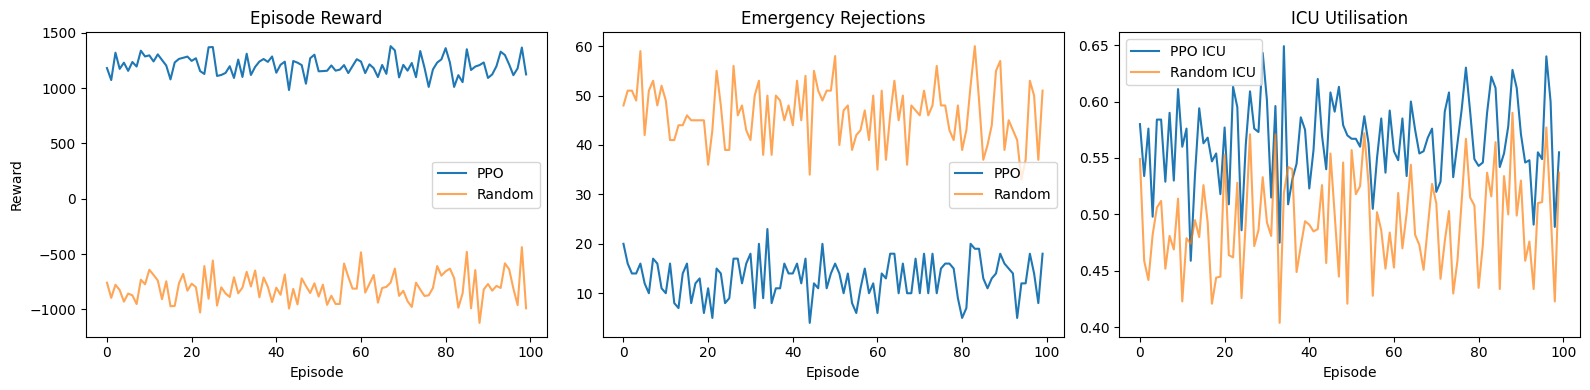

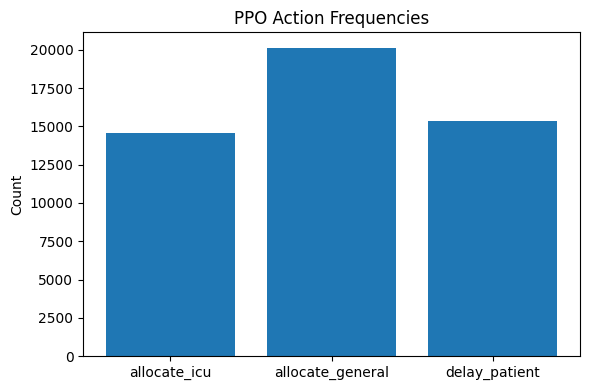

In [24]:

plot_old_env_results(ppo_results, random_results, action_counts_df)


## Save Old-Environment Outputs
Save the model and CSV files only after the cells above have run successfully.

In [19]:
save_old_env_results(model, ppo_results, random_results, summary_df, action_counts_df)


Saved PPO model: ppo_old_env_model.zip
Saved PPO results: ppo_old_env_evaluation_results.csv
Saved random baseline: random_old_env_results.csv
Saved comparison summary: ppo_old_env_vs_random_summary.csv
Saved action counts: ppo_old_env_action_counts.csv


## Final Note
This notebook is a fallback PPO experiment using the older Part 1b bed-allocation environment.

In [20]:
print("Old-environment PPO training and evaluation complete.")
print(summary_df)


Old-environment PPO training and evaluation complete.
                     metric     ppo_mean    ppo_std  random_mean  random_std
0              total_reward  1202.670000  86.338897   -800.64000  127.782922
1      emergency_rejections    13.040000   4.087231     46.34000    5.961526
2      mean_icu_utilisation     0.565290   0.037582      0.49338    0.041986
3  mean_general_utilisation     0.746007   0.023539      0.34280    0.048686
4          delayed_patients   153.230000  12.131314    166.46000   10.190528
